# Research Object


We aim to leverage intuitive techniques such as frequent item mining and clustering algorithms to construct an efficient and easily understandable spam classification model.
This model does not rely on large-scale training data or extensive parameter tuning, yet is capable of achieving fast and accurate classification performance.

# Project outline
This project makes use of both **high-frequency word** and **semantic information** to improve spam message detection.


1. **High-Frequency Word Features**
   - We apply the **Apriori** algorithm to the spam messages in the training set to mine frequent word itemsets that are associated with spam highly.
   - Based on the mined patterns, we construct a **26-dimensional binary feature vector** for each message, where each dimension indicates whether a particular spam-related high-frequency word appears.

2. **Semantic Features**
   - **Fine-tune DistilBERT** obtains semantic embeddings of each message.
   - The embeddings are clustered using **HDBSCAN**.
   - For each message, we compute **soft cluster assignment probabilities** using **cosine similarity** to cluster centroids.
   - This yields a **3-dimensional semantic feature vector** (including a noise cluster).

3. **Binary Classification**
   - Finally we concatenat these features into a **29-dimensional combined feature vector**, which is used as input to a **Logistic Regression** classifier for spam vs. ham prediction.

---

Course Topics Used: Apriori (Frequent Itemset Mining), HDBSCAN (Clustering)

Extra Techniques: DistilBERT (Fine-tuned Semantic Representation), Logistic Regression and Cosine Similarity (for soft assignment)


# Dataset Processing
The dataset used in this study is the **SMS Spam Collection Dataset**, which is publicly available on Kaggle 
(https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset).

## Loading the dateset and Splitting into traning and test sets

In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import random
import numpy as np
import torch

# Set random seed for reproducibility
def set_random_seed(seed=42):
    random.seed(seed)  # Python random module seed
    np.random.seed(seed)  # NumPy random module seed
    torch.manual_seed(seed)  # PyTorch random seed
    torch.cuda.manual_seed_all(seed)  # Set random seed for all GPUs if using GPU
    torch.backends.cudnn.deterministic = True  # Ensure consistent results
    torch.backends.cudnn.benchmark = False  # Disable cudnn auto-optimization
    os.environ['PYTHONHASHSEED'] = str(seed)  # Set Python hash seed


Attention: you may need to download the packages below

In [2]:
# pip install hdbscan
# pip install transformers
# pip install mlxtend

In [3]:
# Get Current Working Directory
current_directory = os.path.dirname(os.path.abspath('__file__'))

# Assume `spam_sms.csv` is in the same directory as the notebook
data_file_path = os.path.join(current_directory, 'spam_sms.csv')

# Load the dataset
data = pd.read_csv(data_file_path)

# Show the first few rows of the data to ensure it is loaded correctly
print(data.head())

# Assign features and labels
X = data['v2']  # text column
y = data['v1']  # label column (1 for spam, 0 for ham)

# Let's map 'spam' to 1 and 'ham' to 0
y = y.map({'spam': 1, 'ham': 0})

# Assume X is of Series type, you can convert it to DataFrame type
if isinstance(X, pd.Series):
    X = X.to_frame()

# Split the dataset into training and testing sets, 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# print(type(X_train))
# Check the size of training and testing sets
print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

# Check the number of Spam (spam messages) in the training set
spam_count = (y_train == 1).sum()  # Count the number of Spam in the training set
print(f"Training set spam messages count: {spam_count}")

print(type(X_train))
print(type(y_train))

     v1                                                 v2
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Training set size: 4457
Testing set size: 1115
Training set spam messages count: 598
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


The dataset contains a total of 5,572 labeled SMS messages, each annotated as either ham (legitimate) or spam. The dataset is imbalanced, with spam messages accounting for approximately 13% of the total samples.

The dataset was split into 80% training and 20% testing sets using the stratify pa-
rameter to maintain the spam ratio.

# Experiment:

## Frequent Itemset Extraction for Spam Detection

We observed that spam messages often contain specific patterns such as monetary amounts, phone numbers, and URLs.  
To normalize these patterns, we applied regex-based labeling with the following rules:

- Replace monetary amounts with `CURRENCY`
- Replace phone numbers with `PHONE_NUMBER`
- Replace URLs with `URL`

This labeling helps the model focus on core textual features by reducing unnecessary variation in numeric and structural patterns. So now we would apply PCY to realize this processing step.

## 1. PCY: Enhancing Spam Detection Using High-Frequency Words from Spam Messages


### 1.1 Information Labeling

We first normalize structured information in the messages by identifying and replacing patterns such as phone numbers, currency amounts, and URLs with placeholder tokens. This reduces irrelevant variance and emphasizes informative textual content.

In [4]:
import re
# add backspaces around labels for easier tokenization
def preprocess_text(text):

    # 1. replace amounts: recognize various amount formats, including £, $, €, ¥, and "p" as units (e.g., 10p/min)
    # amount_pattern = r"(å?£|\$|\€|¥|GBP)\d{1,3}(?:[\.,]?\d+)?(p|per|pounds|dollars|cents)?|(\d{1,3})(p|ppm|min|msg)?"
    # text = re.sub(amount_pattern, " CURRENCY ", text)
    
    amount_pattern = r"""
        (?:(\£|\$|\€|\¥|GBP)\s*(\d+(?:[\.,]\d{1,2})?))  # Match "currency symbol + number" (e.g., £10, $10.99), group 1 stores symbol, group 2 stores number
        |                                           # or
        (\d+(?:[\.,]\d{1,2})?)\s*(p(?=/|\s)|ER|pounds)     # Number + p(/ or space) or Number + ER
    """

    # replace logic: dynamically replace based on matched groups, retaining necessary parts
    text = re.sub(
        amount_pattern, 
        # currency symbol scenario: symbol + space + CURRENCY + space (spaces on both sides)
        lambda m: f"{m.group(1)} CURRENCY " if m.group(1)  
        # number + unit scenario: space + CURRENCY + space + unit (spaces on both sides)
                else f" CURRENCY {m.group(4)}",  
        text, 
        flags=re.VERBOSE | re.IGNORECASE  # ignore uppercase and lowercase
    )

    # 3. Replace URLs: recognize URLs starting with www. or http(s)://
    url_pattern = r"(https?://)?([wW]{3}\.)[a-zA-Z0-9-]+\.[a-zA-Z]{2,6}(\.[a-zA-Z]{2,6})?(/[\w\-\.]+)*(/[\w\-\.]+[\?=\w]+)?"
    text = re.sub(url_pattern, " URL ", text)

    # step 2: process phone numbers (continuous 5-18 digits, simple and direct)
    # replace phone numbers: match 5 to 15 digit numbers, support various formats
    # # Regex explanation: \d{5,18} → matches 5 to 18 consecutive digits; (?<!\w) and (?!\w) prevent digits from being wrapped by letters (e.g., abc12345def will not match)
    # phone_pattern = r"(?<!\w)\d{5,18}(?!\w)"
    # text = re.sub(phone_pattern, " PHONE_NUMBER ", text)

    # match phone numbers with spaces/hyphens, total digits 5-18, not wrapped by letters
    phone_pattern = r"(?<!\w)(?:\d{1,4}[ -]?){1,4}\d{1,4}(?!\w)"

    # define a replacement function to check digit count
    def replace_phone(match):
        pure_digits = match.group(0).replace(" ", "").replace("-", "")
        return " PHONE_NUMBER " if 5 <= len(pure_digits) <= 18 else match.group(0)

    text = re.sub(phone_pattern, replace_phone, text)

    # delete common punctuation marks (such as periods, commas, semicolons, etc.) but keep currency symbols
    # text = re.sub(r"[^\w\s£$€¥]", "", text) # remove punctuation, keep letters, numbers, spaces, and currency symbols

    return text

# # 3. Preprocess the text data
X_train_processed = X_train ['v2'].apply (preprocess_text) # only process text column v2, result is a Series
X_test_processed = X_test ['v2'].apply (preprocess_text)

Select sample messages to check if the labeling meets the expected requirements:

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Assume X_train_processed is the preprocessed spam SMS data (y_train == 1)
spam_data_sample = X_train[y_train == 1]['v2']   # choose spam messages

# choose a spam message sample (assuming we choose the 11th sample)
sample_text = spam_data_sample.iloc[10] # choose the 11th spam message sample
print("Original Sample Text:")
print(sample_text)

# preprocess the text
processed_text = preprocess_text(sample_text)
print("\nProcessed Text:")
print(processed_text)

# Use CountVectorizer to extract the word frequency matrix for the sample
vectorizer = CountVectorizer(stop_words='english', tokenizer=lambda x: x.split())  # Apply Tokenization
X_sample = vectorizer.fit_transform([processed_text])  # Transform the sample into a word frequency matrix

# Get the vocabulary and word frequencies for the sample
words = vectorizer.get_feature_names_out()  # Get the vocabulary for the sample
word_counts = X_sample.toarray().flatten()  # Get the word frequencies for the sample

# Combine the vocabulary and word frequencies into a DataFrame
word_freq_df = pd.DataFrame(list(zip(words, word_counts)), columns=['Word', 'Frequency'])

# output word frequency results
print("\nWord Frequency Results:")
print(word_freq_df)

Original Sample Text:
PRIVATE! Your 2003 Account Statement for shows 800 un-redeemed S.I.M. points. Call 08718738001 Identifier Code: 49557 Expires 26/11/04

Processed Text:
PRIVATE! Your 2003 Account Statement for shows 800 un-redeemed S.I.M. points. Call  PHONE_NUMBER  Identifier Code:  PHONE_NUMBER  Expires 26/11/04

Word Frequency Results:
            Word  Frequency
0           2003          1
1       26/11/04          1
2            800          1
3        account          1
4          code:          1
5        expires          1
6     identifier          1
7   phone_number          2
8        points.          1
9       private!          1
10        s.i.m.          1
11         shows          1
12     statement          1
13   un-redeemed          1


c:\Users\mingx\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [6]:
spam_data = X_train_processed[y_train == 1]  # Choose y_train = 1 as spam text
ham_data = X_train_processed[y_train == 0]  # Choose y_train = 0 as ham text

# Process spam data
spam_data['processed_text'] = spam_data.apply(preprocess_text)  # Apply preprocessing to the text column
spam_data['contains_currency'] = spam_data['processed_text'].apply(lambda x: 'CURRENCY' in x)
spam_data['contains_phone'] = spam_data['processed_text'].apply(lambda x: 'PHONE_NUMBER' in x)
spam_data['contains_url'] = spam_data['processed_text'].apply(lambda x: 'URL' in x)

# Process ham data
ham_data['processed_text'] = ham_data.apply(preprocess_text)  # Apply preprocessing to the text column
ham_data['contains_currency'] = ham_data['processed_text'].apply(lambda x: 'CURRENCY' in x)
ham_data['contains_phone'] = ham_data['processed_text'].apply(lambda x: 'PHONE_NUMBER' in x)
ham_data['contains_url'] = ham_data['processed_text'].apply(lambda x: 'URL' in x)

# calculate the number of samples containing these elements in each category
spam_currency_count = spam_data['contains_currency'].sum()
spam_phone_count = spam_data['contains_phone'].sum()
spam_url_count = spam_data['contains_url'].sum()

ham_currency_count = ham_data['contains_currency'].sum()
ham_phone_count = ham_data['contains_phone'].sum()
ham_url_count = ham_data['contains_url'].sum()

# obtain the total number of spam and ham messages
spam_total_count = len(spam_data)
ham_total_count = len(ham_data)

# calculate ratios
spam_currency_ratio = spam_currency_count / spam_total_count
spam_phone_ratio = spam_phone_count / spam_total_count
spam_url_ratio = spam_url_count / spam_total_count

ham_currency_ratio = ham_currency_count / ham_total_count
ham_phone_ratio = ham_phone_count / ham_total_count
ham_url_ratio = ham_url_count / ham_total_count

# Summarize results into a DataFrame
summary = pd.DataFrame({
    'Category': ['Spam Messages', 'Ham Messages'],
    'Total Count': [spam_total_count, ham_total_count],
    'Currency Samples': [spam_currency_count, ham_currency_count],
    'Phone Number Samples': [spam_phone_count, ham_phone_count],
    'URL Samples': [spam_url_count, ham_url_count],
    'Currency Ratio': [spam_currency_ratio, ham_currency_ratio],
    'Phone Number Ratio': [spam_phone_ratio, ham_phone_ratio],
    'URL Ratio': [spam_url_ratio, ham_url_ratio]
})

# result output
print(summary)


        Category  Total Count  Currency Samples  Phone Number Samples  \
0  Spam Messages          602               296                   463   
1   Ham Messages         3863                 9                     1   

   URL Samples  Currency Ratio  Phone Number Ratio  URL Ratio  
0           81        0.491694            0.769103   0.134551  
1            6        0.002330            0.000259   0.001553  


### 1.2 Extracting High-Frequency Words with the PCY Algorithm

Using the **PCY frequent itemset mining algorithm**, we identify high-frequency words or word combinations that appear predominantly in spam messages.

We applied the Apriori algorithm to extract frequent itemsets from the spam subset of the training data.  
The `min_support` was set to **0.1** to capture as many potential features as possible.  
This relatively small threshold was chosen for two main reasons:

- Some features may occur with low frequency, yet still serve as strong indicators of spam behavior.
- Subsequent classifiers (such as logistic regression) can automatically learn and adjust the importance of each feature during training, so retaining a wide range of candidate features is beneficial.

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from mlxtend.frequent_patterns import apriori, association_rules

# Assume spam_train and ham_train are already Series types, convert to DataFrame types
spam_train = X_train_processed[y_train == 1]  # choose spam messages
ham_train = X_train_processed[y_train == 0]  # choose ham messages

# Define a custom tokenizer that excludes numbers and periods
def custom_tokenizer(text):
    tokens = text.split()  # Split by whitespace
    # Keep only non-numeric and non-period tokens
    filtered_tokens = [token for token in tokens if not token.isdigit() and token != '.']
    return filtered_tokens

# Use CountVectorizer to extract term frequency matrix, excluding numbers and periods
# Take countervectorizer for spam messages as example
vectorizer_spam = CountVectorizer(stop_words='english', tokenizer=custom_tokenizer)
X_train_spam = vectorizer_spam.fit_transform(spam_train)  # convert spam messages into term frequency matrix

# Create a separate CountVectorizer instance for ham messages
vectorizer_ham = CountVectorizer(stop_words='english', tokenizer=custom_tokenizer)
X_train_ham = vectorizer_ham.fit_transform(ham_train)  # convert ham messages into term frequency matrix

# Convert term frequency matrix to boolean matrix (0 or 1) indicating presence of the word
X_train_spam_bin = (X_train_spam > 0).astype(int)
X_train_ham_bin = (X_train_ham > 0).astype(int)

# get feature names (vocabulary) from the vectorizers
words_spam = vectorizer_spam.get_feature_names_out()  # get vocabulary for spam messages
words_ham = vectorizer_ham.get_feature_names_out()  # get vocabulary for ham messages

# the boolean matrix conversion to DataFrame
df_spam_train = pd.DataFrame(X_train_spam_bin.toarray(), columns=words_spam)
df_ham_train = pd.DataFrame(X_train_ham_bin.toarray(), columns=words_ham)

# Use Apriori algorithm to extract frequent itemsets
spam_frequent_itemsets = apriori(df_spam_train, min_support=0.1, use_colnames=True)
spam_frequent_itemsets_sorted = spam_frequent_itemsets.sort_values(by='support', ascending=False)

ham_frequent_itemsets = apriori(df_ham_train, min_support=0.1, use_colnames=True)
ham_frequent_itemsets_sorted = ham_frequent_itemsets.sort_values(by='support', ascending=False)

# Frequent itemsets output
print("spam frequent itemsets: ")
print(spam_frequent_itemsets_sorted)
print("ham frequent itemsets: ")
print(ham_frequent_itemsets_sorted)

# Extract all words from frequent itemsets
spam_high_freq_words = set()
# Extract all frequent itemsets from spam messages, keeping combinations
spam_high_freq_words = []

for itemset in spam_frequent_itemsets_sorted['itemsets']:
    spam_high_freq_words.append(itemset)  # add all frequent itemsets (tuples) to the list

# output all high-frequency word combinations
print("spam high-frequency word combinations:")
print(spam_high_freq_words)
print(len(spam_high_freq_words))

c:\Users\mingx\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\mingx\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(
c:\Users\mingx\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


spam frequent itemsets: 
     support                       itemsets
5   0.774247                 (phone_number)
2   0.494983                     (currency)
15  0.434783       (currency, phone_number)
12  0.309365                           (å£)
18  0.309365                 (currency, å£)
23  0.284281             (phone_number, å£)
25  0.284281   (currency, phone_number, å£)
3   0.195652                         (free)
8   0.170569                          (txt)
19  0.155518           (phone_number, free)
10  0.152174                           (ur)
20  0.147157            (phone_number, txt)
1   0.138796                        (claim)
9   0.137124                            (u)
11  0.135452                          (url)
6   0.127090                        (reply)
22  0.125418             (ur, phone_number)
7   0.123746                         (text)
14  0.120401          (claim, phone_number)
16  0.118729                (currency, txt)
4   0.115385                       (mobile)
21  0.1

The frequent itemsets in the spam and ham subsets differ significantly.  
Most frequent itemsets in the spam subset include tokens such as `PHONE_NUMBER`, `CURRENCY`, `FREE`, `TXT`, and `CLAIM`.  
These words often co-occur in specific combinations (e.g., (`CURRENCY`, `PHONE_NUMBER`) or (`FREE`, `TXT`)), forming distinctive lexical patterns.

In contrast, the ham subset produces almost no meaningful frequent itemsets (e.g., only (`u`)), highlighting the clear difference in message structure.  
These spam-specific patterns provide highly informative features for downstream classifiers.


### 1.3 Constructing High-Frequency Word Feature Vectors

For each message, we check whether it contains each of the extracted high-frequency spam words.  
We then construct a **binary feature vector**, where:
- `1` indicates the word is present,
- `0` indicates the word is absent.

This results in a sparse **0/1 high-frequency word feature representation** for every message.

In [9]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# use existing preprocess_text and custom_tokenizer functions
def feature_matrix_from_word_counts(text, frequent_items):
    # Preprocess the text
    processed_text = preprocess_text(text)
    
    # Use CountVectorizer to extract term frequency matrix, excluding stop words and using custom tokenizer
    vectorizer = CountVectorizer(stop_words='english', tokenizer=custom_tokenizer)
    X = vectorizer.fit_transform([processed_text])  # Convert text to term frequency matrix

    # Get feature names (vocabulary)
    words = vectorizer.get_feature_names_out()

    # Get word counts (frequency of each word)
    word_counts = dict(zip(words, X.toarray().flatten()))  # combine vocabulary and frequency
    
    # Check if the text contains only stop words
    tokens = custom_tokenizer(processed_text)
    non_stopwords = [word for word in tokens if word not in ENGLISH_STOP_WORDS]
    if len(non_stopwords) == 0:
        # If all stop words, return a zero feature vector
        feature_vector = [0] * len(frequent_items)
    else:
        # Generate 01 feature vector: check if each frequent itemset is in the text
        feature_vector = []
        for itemset in frequent_items:
            if itemset.issubset(set(words)):  # use set(words) for subset check
                feature_vector.append(1)
            else:
                feature_vector.append(0)

    return feature_vector, word_counts
# # test example
# sms_text = spam_data_sample.iloc[2]  # select a spam message sample
# print(sms_text)
# # call function
# feature_vector, word_counts = feature_matrix_from_word_counts(sms_text, spam_high_freq_words)

# # Output results
# print("Feature vector:", feature_vector)
# print("Word counts:", word_counts)

In [10]:
# Choose any sample from X_train
sample_text = X_train.iloc[0]['v2']  # 'v2' is the column containing text

# call function
feature_vector, word_counts = feature_matrix_from_word_counts(sample_text, spam_high_freq_words)

# Output results
print("Feature vector:", feature_vector)
print("Word counts:", word_counts)

Feature vector: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Word counts: {'going': np.int64(1), 'great.bye': np.int64(1)}


c:\Users\mingx\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [11]:
# Use safe_feature_matrix_from_word_counts to handle potential errors
def safe_feature_matrix_from_word_counts(text, frequent_items):
    try:
        feature_vector, word_counts = feature_matrix_from_word_counts(text, frequent_items)
    except ValueError:
        # If an error occurs, print a warning and return a zero feature vector
        print(f"Warning: empty vocabulary or stop words only for text: {text[:100]}...")  #print partial text to avoid long output
        feature_vector = [0] * len(frequent_items)  # Zero feature vector
        word_counts = {}  # Empty word counts
    return feature_vector

# Continue using this method to process X_train and X_test
X_train['words_feature'] = [
    safe_feature_matrix_from_word_counts(text, spam_high_freq_words) for text in X_train['v2']
]
X_test['words_feature'] = [
    safe_feature_matrix_from_word_counts(text, spam_high_freq_words) for text in X_test['v2']
]

# Output X_train and X_test to see the added feature columns
print(X_train.head())
print(X_test.head())


c:\Users\mingx\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


                                                     v2  \
184                          Going on nothing great.bye   
2171                      I wont. So wat's wit the guys   
5422            Ok k..sry i knw 2 siva..tats y i askd..   
4113  Where are you ? What do you do ? How can you s...   
4588       Have you not finished work yet or something?   

                                          words_feature  
184   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
2171  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
5422  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
4113  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
4588  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
                                                     v2  \
2826  Oh right, ok. I'll make sure that i do loads o...   
3695                     I am in tirupur.  call you da.   
3906             No that just means you have a fat head   
575   You have won ?1,000 cash or a ?2,000 prize! To...   
28

We first trained a Logistic Regression model using only the word feature vectors to assess performance. The key issue is the **recall** on spam messages: although precision is high, recall is relatively low. In practice, this means roughly **12% of spam messages were missed**, i.e., they were incorrectly classified as normal (false negatives). Next, we extracted semantic features from the messages, hoping to further improve the model’s performance.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# X_train['words_feature'] store multi-dimensional arrays, each sample is a feature vector
# y_train is the labels (e.g., spam: 1, ham: 0)

# convert X_train['words_feature'] to a suitable array format for training
X_train_features = list(X_train['words_feature'])  # get the feature vector list for each text

# create logistic regression model
model = LogisticRegression(max_iter=1000)  # max_iter set to 1000 to ensure sufficient iterations

# train the model
model.fit(X_train_features, y_train)

# make predictions (e.g., on the training set)
y_pred = model.predict(X_train_features)

# Accuracy output
accuracy = accuracy_score(y_train, y_pred)
print(f"train set accuracy: {accuracy:.4f}")

X_test_features = list(X_test['words_feature'])  # get the feature vector list for each text

# make predictions (e.g., on the test set)
y_test_pred = model.predict(X_test_features)

# calculate and output accuracy
accuracy_test = accuracy_score(y_test, y_test_pred)
print(f"test set accuracy: {accuracy_test:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# make predictions (e.g., on the test set)
y_test_pred = model.predict(X_test_features)

# confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print("confusion matrix:")
print(cm)

# precision, recall, and F1-Score
report = classification_report(y_test, y_test_pred, target_names=['ham', 'spam'])
print("classification report (precision, recall, F1-Score):")
print(report)

train set accuracy: 0.9829
test set accuracy: 0.9794
confusion matrix:
[[961   5]
 [ 18 131]]
classification report (precision, recall, F1-Score):
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       966
        spam       0.96      0.88      0.92       149

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



## 2. Semantic Clustering for Spam Detectionn

### 2.1 Semantic Extraction with Fine-tuned BERT Encoder

We trained a **fine-tuned DistilBERT-base-uncased** model to encode each SMS message into a high-dimensional semantic vector. We adopt this fine-tuned DistilBERT model for two main reasons:

- **DistilBERT** is a lightweight and efficient version of BERT, well-suited for short and concise SMS messages.
- Fine-tuning refines the embedding space, making spam and ham messages more separable and easier to cluster.

Each message was encoded into a **768-dimensional semantic vector**.


In [21]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
import torch
# set a seed
set_random_seed(42)

# 1. Load the pre-trained DistilBERT model and tokenizer (for fine-tuning)
finetune_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
finetune_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2, output_hidden_states=True)

# 2. Data Preprocessing (Preparing SMS messages for DistilBERT)
def encode_text(texts):
    return finetune_tokenizer(texts.tolist(), padding=True, truncation=True, max_length=128, return_tensors='pt')

# test and train set encodings
finetune_train_encodings = encode_text(X_train['v2'])
finetune_test_encodings = encode_text(X_test['v2'])

# train and test set labels
finetune_train_labels = torch.tensor(y_train.tolist())
finetune_test_labels = torch.tensor(y_test.tolist())

# 3. creat dataset and dataloading functions
class SMSDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

# Dataset Example
finetune_train_dataset = SMSDataset(finetune_train_encodings, finetune_train_labels)
finetune_test_dataset = SMSDataset(finetune_test_encodings, finetune_test_labels)

# 4. Training configuration (minimized to ensure it runs successfully)
training_args = TrainingArguments(
    output_dir='./results',  # Directory to store results
    num_train_epochs=1,  # Set to 1 epoch for quick code validation
    per_device_train_batch_size=64,  # Use smaller batch size
    per_device_eval_batch_size=64,  # Use smaller batch size
    save_steps=500,  # Save model every 500 steps
    logging_dir='./logs',  # Directory to store logs
    logging_steps=10,  # Log every 10 steps
    save_strategy="steps",  # Save model every 500 steps
)

# 5.fine tuning by Trainer
finetune_trainer = Trainer(
    model=finetune_model,
    args=training_args,
    train_dataset=finetune_train_dataset,
    eval_dataset=finetune_test_dataset,
)

# 6.begin trainning
finetune_trainer.train()

# 7. Training Set Evaluation
train_results = finetune_trainer.evaluate(eval_dataset=finetune_train_dataset)
print(f"Training set evaluation results: {train_results}")

# 8. Extract [CLS] embeddings as semantic representations
finetune_model.eval()

# Save semantic representations for train/test sets
train_finetuning_semantic = []
test_finetuning_semantic = []

with torch.no_grad():
    # deal with train set
    for batch in torch.utils.data.DataLoader(finetune_train_dataset, batch_size=16):
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']

        outputs = finetune_model(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs.hidden_states[-1]
        cls_embeddings = last_hidden_state[:, 0, :]
        train_finetuning_semantic.extend(cls_embeddings.cpu().numpy())
    
    # deal with test set
    for batch in torch.utils.data.DataLoader(finetune_test_dataset, batch_size=16):
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']

        outputs = finetune_model(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs.hidden_states[-1]
        cls_embeddings = last_hidden_state[:, 0, :]
        test_finetuning_semantic.extend(cls_embeddings.cpu().numpy())

# Print semantic representations of the first five samples
print("Semantic representations of the first five training samples ([CLS] token embeddings):")
for i in range(5):
    print(f"Sample {i+1}: {train_finetuning_semantic[i]}")

print("\nSemantic representations of the first five test samples ([CLS] token embeddings):")
for i in range(5):
    print(f"Sample {i+1}: {test_finetuning_semantic[i]}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\mingx\AppData\Local\Temp\ipykernel_20528\4179492824.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Step,Training Loss
10,0.399700
20,0.112300
30,0.072100
40,0.040800
50,0.040900
60,0.029900
70,0.039900


C:\Users\mingx\AppData\Local\Temp\ipykernel_20528\4179492824.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Training set evaluation results: {'eval_loss': 0.028303995728492737, 'eval_runtime': 264.2268, 'eval_samples_per_second': 16.868, 'eval_steps_per_second': 0.265, 'epoch': 1.0}
Semantic representations of the first five training samples ([CLS] token embeddings):
Sample 1: [-4.07913357e-01  4.63434219e-01 -1.02445555e+00 -5.05696416e-01
 -3.75943720e-01 -1.00204778e+00  9.11944091e-01 -3.42427790e-02
 -2.97337651e-01 -1.09175670e+00 -5.13809919e-01 -1.49158642e-01
 -6.16033435e-01  1.05308509e+00 -3.72066319e-01 -6.10130847e-01
  3.13262433e-01 -2.97797978e-01 -9.72433448e-01  7.34680831e-01
 -6.73040748e-01 -4.90503013e-02 -2.79989600e-01  8.18631768e-01
 -8.64849329e-01 -3.69057715e-01  1.05933583e+00  1.20101780e-01
 -9.41442370e-01 -7.35568941e-01  5.82846701e-01 -9.98324007e-02
 -4.01404113e-01 -3.70274454e-01  6.60091341e-02 -8.79449248e-01
 -4.74979132e-01  7.06786931e-01 -2.08801538e-01  8.26879740e-01
  5.46415985e-01 -7.53013790e-02 -8.47194344e-04  1.68217137e-01
  1.78981632e

### 2.2 HDBSCAN for Semantic Grouping

We then applied **HDBSCAN** on the 768-dimensional semantic embeddings obtained from the fine-tuned DistilBERT model to group messages with similar meanings. 

In [22]:
import hdbscan

# Convert vectors to numpy array
train_finetuning_array = np.array(train_finetuning_semantic)

# Initialize HDBSCAN clusterer for fine-tuning
finetune_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=30,  
    min_samples=30
)

# Execute clustering on fine-tuning semantic vectors
finetune_cluster_labels = finetune_clusterer.fit_predict(train_finetuning_array)

# Count clustering results
unique_labels = np.unique(finetune_cluster_labels)
n_clusters = len(unique_labels[unique_labels != -1])
n_noise = list(finetune_cluster_labels).count(-1)

# Output clustering results
print(f"Identified {n_clusters} clusters, number of noise samples: {n_noise}")
print(f"Cluster labels for each sample: {finetune_cluster_labels}")

c:\Users\mingx\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\mingx\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Identified 2 clusters, number of noise samples: 22
Cluster labels for each sample: [0 0 0 ... 1 1 0]


We ran HDBSCAN on the fine-tuned semantic embeddings. It produced 2 clusters, and only 22 points were marked as noise, which suggests the embeddings are well separated. Next, we examined the number of noise points (cluster label = -1) and the spam purity within the two clusters. 
There are only 22 noise samples, and both clusters show near 100% purity, clearly separating spam and non-spam messages as expected.

In [23]:
import numpy as np
import pandas as pd

# Cluster labels and actual labels combined into DataFrame
cluster_df = pd.DataFrame({
    'cluster_label': finetune_cluster_labels,  # Used fine-tuned clustering result labels
    'actual_label': y_train           
})

# Group by cluster label and aggregate
cluster_stats = cluster_df.groupby('cluster_label').agg(
    total_samples=('actual_label', 'count'),
    spam_samples=('actual_label', lambda x: sum(x == 1))
).reset_index()

# Calculate spam ratio
cluster_stats['spam_ratio'] = cluster_stats['spam_samples'] / cluster_stats['total_samples']

# Display results
print("Spam ratio statistics for each cluster:")
print(cluster_stats.sort_values('cluster_label'))

# Print noise cluster statistics separately
noise_stats = cluster_stats[cluster_stats['cluster_label'] == -1]
if not noise_stats.empty:
    print("\nNoise cluster spam ratio:")
    print(noise_stats[['total_samples', 'spam_samples', 'spam_ratio']])

Spam ratio statistics for each cluster:
   cluster_label  total_samples  spam_samples  spam_ratio
0             -1             22            11    0.500000
1              0           3863            20    0.005177
2              1            572           567    0.991259

Noise cluster spam ratio:
   total_samples  spam_samples  spam_ratio
0             22            11         0.5


As shown in the ouyput, HDBSCAN automatically grouped the messages into two main
clusters. Cluster 0 contains mostly ham messages with a very low spam ratio (0.52%), while
Cluster 1 consists almost entirely of spam messages (99.13%). This matches our expectation
that spam and ham messages should form compact and well-separated clusters in the fine-
tuned semantic space. The small number of noise samples (22 in total) further indicates that
the learned embeddings exhibit a clear structure and strong robustness.

### 2.3 Soft Assignment: Cluster Membership via Cosine Distance

After HDBSCAN, we obtain **2 clusters** plus a **noise label (-1)**.  
For each message embedding, we compute a **3-dimensional soft assignment vector** as follows:

- Compute the **mean cosine similarity** to the exemplar points of each cluster.
- Define the noise score as the **complement of the highest cluster score**.
- Normalize the three scores to obtain a probability distribution.

This produces a semantic feature vector `(p_cluster1, p_cluster2, p_noise)` for each message, which we use as the input to the final classifier.


In [24]:
# 1. deal with core points (exemplar points) of valid clusters
# exemplars_ stores the core exemplar points for each valid cluster in the format of a list of lists
valid_cluster_labels = []
valid_core_counts = []

for label, exemplars in enumerate(finetune_clusterer.exemplars_):
    if exemplars is not None:  # Exclude empty clusters
        valid_cluster_labels.append(label)
        valid_core_counts.append(len(exemplars))

# 2. Deal with noise cluster (-1) core points
# Noise cluster core points can be filtered by "label == -1 and probabilities_ > 0" (noise points with certain belonging strength)
noise_core_mask = (finetune_clusterer.labels_ == -1) & (finetune_clusterer.probabilities_ > 0)
noise_core_count = np.sum(noise_core_mask)

# 3. Combine results and print
print("Number of core points (exemplar points) in each cluster:")
# print valid cluster results
for label, count in zip(valid_cluster_labels, valid_core_counts):
    print(f"Cluster {label}: {count} core points")
# print noise cluster
print(f"Cluster -1: {noise_core_count} core points")


Number of core points (exemplar points) in each cluster:
Cluster 0: 60 core points
Cluster 1: 31 core points
Cluster -1: 0 core points


We highlight two design choices in the soft assignment step:

1. **Cosine similarity** is used because it is well suited for high-dimensional text embeddings.  
   It measures angular similarity and is invariant to vector magnitude, making it a stable metric for semantic comparison.

2. The **noise score** is defined as `1 - max(s_c)` because the noise class represents messages that do *not* belong to any cluster.  
   If a message closely matches a cluster, the noise score is low; if it matches none, the noise score is high.  
   This complementary form also ensures the scores can be normalized into a valid probability vector without introducing a noise centroid.

In [25]:
import hdbscan
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# ----------------------
# core function to generate soft assignment probability vectors
# function: generate soft assignment probability vectors for each semantic vector (train/test samples) to all clusters (valid clusters + noise cluster)
# ----------------------
def get_soft_assignment(semantic_vectors, clusterer, valid_clusters):
    """
    Generate soft assignment probability vectors for input semantic vectors (including valid clusters and noise cluster)
    
    Parameters:
        semantic_vectors: Input semantic vectors (2D array, shape=[num_samples, feature_dim], compatible with both train/test sets)
        clusterer: Trained HDBSCAN clusterer (must contain labels_, exemplars_ and other attributes)
        valid_clusters: List of valid cluster labels (excluding noise cluster -1, e.g., [0,1])
    
    Returns:
        prob_vectors: List of soft assignment probability vectors (each element is 1D array, shape=[num_valid_clusters+1], last position is noise cluster probability)
    """
    # combine valid clusters and noise cluster labels, final probability vector is arranged in this order (e.g., [0,1,-1])
    all_clusters = np.append(valid_clusters, -1)
    # Store all samples' probability vectors
    prob_vectors = []
    
    # Iterate through each sample's semantic vector and compute probabilities
    for vec in semantic_vectors:
        # Adjust vector shape to (1, feature_dim): sklearn's cosine_similarity requires 2D array as input
        sample = vec.reshape(1, -1)
        # Store the "raw strength" (unnormalized) of the current sample to each cluster
        strengths = []
        # Store the "raw strength" (unnormalized) of the current sample to each valid cluster
        valid_strengths = []
        
        # ----------------------
        # Step 1: Calculate the raw strength to each valid cluster (based on cosine similarity)
        # ----------------------
        for cluster_id in valid_clusters:
            # 1. Get the "core exemplar points" of the current valid cluster (HDBSCAN's exemplars_ attribute)
            # exemplars_ is a list of arrays, each array corresponds to a valid cluster's core exemplar points
            exemplars = clusterer.exemplars_[int(cluster_id)]

            # 2. Handle the extreme case where the core points are empty (e.g., very few samples in the cluster, no exemplars selected)
            if exemplars is None:
                # Use all samples in the cluster as temporary core points (ensure there is a reference for calculation)
                # Select the sample indices belonging to the current cluster from the clusterer's labels
                cluster_mask = (clusterer.labels_ == cluster_id)
                # Extract the semantic vectors of these samples as temporary core points
                exemplars = semantic_vectors[cluster_mask]
            
            # 3. Calculate the "average cosine similarity" between the sample and the cluster's core points
            # Cosine similarity measures the consistency of vector directions (core features of semantic vectors), closer to 1 indicates more similarity
            # Taking the average helps avoid偶然误差 from a single core point and more stably reflects cluster relevance
            sim = cosine_similarity(sample, exemplars).mean()

            # 4. Save the strength of the current valid cluster
            strengths.append(sim)       # For the final probability vector
            valid_strengths.append(sim) # Save separately for later noise cluster calculation

        # ----------------------
        # Step 2: Calculate the raw strength of the noise cluster (core logic: 1 - max valid cluster similarity)
        # ----------------------
        # First get the "maximum similarity" of the sample to all valid clusters: represents the sample's most likely association with valid clusters
        max_valid_strength = max(valid_strengths) if valid_strengths else 0.0

        # Key logic: noise cluster strength = 1 - max valid cluster similarity
        noise_strength = 1.0 - max_valid_strength
        
        # Append noise cluster strength to the original strengths list (now strengths length = number of valid clusters + 1)
        strengths.append(noise_strength)
        
        # ----------------------
        # Step 3: Normalize the raw strengths to obtain the final probability vector
        # ----------------------
        # Convert to numpy array for easier calculation
        strengths = np.array(strengths)
        # Avoid division by zero (extreme case: all strengths are zero, set probabilities to uniform distribution)
        if strengths.sum() > 0:
            # Normalization: divide all strengths by their sum to ensure the result sums to 1 (consistent with probability definition)
            strengths = strengths / strengths.sum()

        # Append the current sample's probability vector to the result list
        prob_vectors.append(strengths)
    
    # return the list of probability vectors for all samples
    return prob_vectors

# ----------------------
# 2. Process training and testing sets to generate soft assignment probability vectors
# ----------------------
valid_clusters = np.unique(finetune_clusterer.labels_)
valid_clusters = valid_clusters[valid_clusters != -1]

# Generate soft assignment probability vectors for the training set
train_prob_vectors = get_soft_assignment(
    train_finetuning_semantic, 
    finetune_clusterer, 
    valid_clusters
)

# Generate soft assignment probability vectors for the testing set
test_prob_vectors = get_soft_assignment(
    test_finetuning_semantic, 
    finetune_clusterer, 
    valid_clusters
)

# ----------------------
# 3. Add probability vectors to X_train and X_test
# ----------------------
X_train['semantic_feature'] = list(train_prob_vectors)
X_test['semantic_feature'] = list(test_prob_vectors)

# # validation（check semantic_feature）
# print("train semantic_feature：")
# for i in range(10):
#     print(X_train['semantic_feature'].iloc[i].round(4))

# print("test semantic_feature：")
# for i in range(10):
#     print(X_test['semantic_feature'].iloc[i].round(4))


## 3. Feature Concatenation

Next, We combine the 26-dimensional word features (`word_feature`) with the 3-dimensional semantic features (`semantic_feature`) to form a **29-dimensional input vector** for binary classification. 

Before training, the data is **split into training and test sets** and **standardized** to ensure that all feature dimensions have comparable numerical scales.


In [26]:
print("X_train type:", type(X_train))
print("X_test type:", type(X_test))
# concate semantic_feature (26D) and words_feature (3D) into a 29D vector column
X_train['combined_feature'] = X_train.apply(
    lambda row: np.concatenate([row['semantic_feature'], row['words_feature']]), 
    axis=1
)
X_test['combined_feature'] = X_test.apply(
    lambda row: np.concatenate([row['semantic_feature'], row['words_feature']]), 
    axis=1
)

# validation (check combined_feature)
print("X_train combined_feature length:", len(X_train['combined_feature'].iloc[0])) 
print("X_test combined_feature length:", len(X_test['combined_feature'].iloc[0]))  

X_train type: <class 'pandas.core.frame.DataFrame'>
X_test type: <class 'pandas.core.frame.DataFrame'>
X_train combined_feature length: 29
X_test combined_feature length: 29


## 4.Binary Classification + Result Evaluation

### 4.1 Compare Logistic Regression (no regularization) vs. Random Forest

In [27]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

# Key correction: extract the combined_feature column from DataFrame and convert it to a 2D array
# Each sample is a 29-dimensional vector, need to convert to an array of shape (number of samples, 29)
X_train_feat = np.array(X_train['combined_feature'].tolist())  # Extract training features
X_test_feat = np.array(X_test['combined_feature'].tolist())    # Extract testing features

# Train logistic regression (need to standardize)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)  # Use extracted feature array
X_test_scaled = scaler.transform(X_test_feat)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# Train random forest (use original features directly)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_feat, y_train)  # Use extracted feature array
y_pred_rf = rf_model.predict(X_test_feat)

# Output key metrics
print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("Logistic Regression F1 Score:", round(f1_score(y_test, y_pred_lr, zero_division=0), 4))
print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Random Forest F1 Score:", round(f1_score(y_test, y_pred_rf, zero_division=0), 4))

# Select the best model
print("\nBest Model:", "Random Forest" if f1_score(y_test, y_pred_rf) > f1_score(y_test, y_pred_lr) else "Logistic Regression")


Logistic Regression Accuracy: 0.9919
Logistic Regression F1 Score: 0.9693
Random Forest Accuracy: 0.9883
Random Forest F1 Score: 0.9556

Best Model: Logistic Regression


We evaluated two classification models in our experiments: logistic regression and random forest.  
Logistic regression showed more stable performance and better interpretability when the data was nearly linearly separable.

**Results:**
- Logistic Regression: Accuracy = 0.9919, F1 = 0.9693
- Random Forest: Accuracy = 0.9883, F1 = 0.9556

Overall, logistic regression outperformed random forest in this task, and therefore we selected it as the primary model for subsequent analysis.

### 4.2 Result Analysis

Since the dataset is imbalanced, we mainly evaluate the model using metrics that reflect the minority class performance, including ROC and PR curves and the confusion matrix.


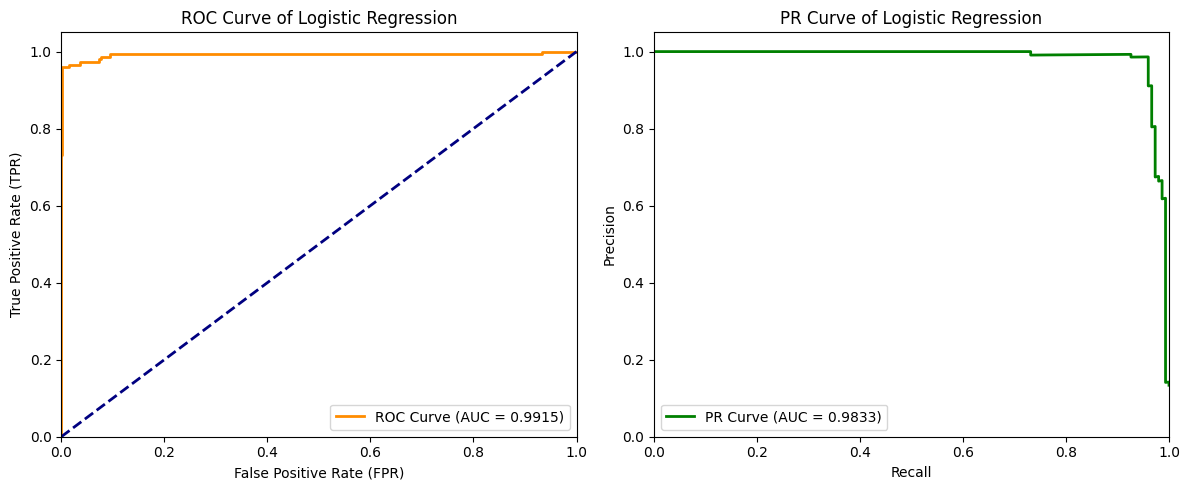

=== Detailed Evaluation of Logistic Regression ===


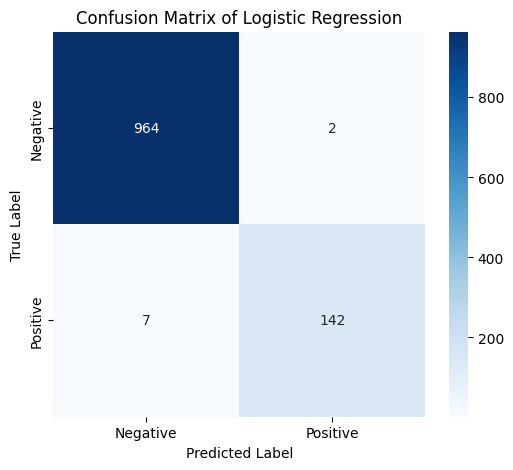


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       966
           1       0.99      0.95      0.97       149

    accuracy                           0.99      1115
   macro avg       0.99      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115


AUC-ROC: 0.9915
AUC-PR: 0.9833


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)
import seaborn as sns

# 1. Get predicted probabilities for Logistic Regression (for curve plotting)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]  # Probability of positive class

# 2. Calculate ROC curve and AUC-ROC
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_lr)
roc_auc = auc(fpr, tpr)

# 3. Calculate PR curve and AUC-PR
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba_lr)
pr_auc = average_precision_score(y_test, y_proba_lr)  # More accurate PR-AUC calculation

# 4. Plot ROC curve and PR curve
plt.figure(figsize=(12, 5))

# Left: ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Random baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve of Logistic Regression')
plt.legend(loc="lower right")

# Right: PR Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='green', lw=2, label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve of Logistic Regression')
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

# 5. Output detailed classification metrics (Confusion Matrix, Classification Report)
print("=== Detailed Evaluation of Logistic Regression ===")
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of Logistic Regression')
plt.show()

# Classification Report (contains Precision, Recall, F1-Score, etc.)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

# Output AUC values
print(f"\nAUC-ROC: {roc_auc:.4f}")
print(f"AUC-PR: {pr_auc:.4f}")

**Results Analysis**

· As shown in ROC Curve figures, the ROC curve of the logistic regression model is close to the upper-left corner, with an AUC of **0.9915**. This indicates that the model achieves strong discrimination between spam and non-spam messages, maintaining a very low false positive rate (FPR) while achieving a high true positive rate (TPR).

· Figure (PR Curve) presents the Precision-Recall (PR) curve of Logistic Regression. The AUC reaches **0.9833**, which is also near 1. This demonstrates that the model maintains high performance even under class imbalance. The curve’s shape indicates that the model is able to correctly identify most spam messages while keeping precision high.

· The confusion matrix in final Figure shows that only **2 non-spam messages** were misclassified as spam, and **7 spam messages** were incorrectly labeled as non-spam. This means the model rarely produces false alarms and generally maintains high recall when identifying spam.

**In summary**, logistic regression performs consistently well in this task, achieving high precision, recall, and overall accuracy. The model can effectively identify spam messages while keeping false detections at a very low level.
